## Lesson Overview

https://www.youtube.com/watch?v=aeFwbsTJQgs

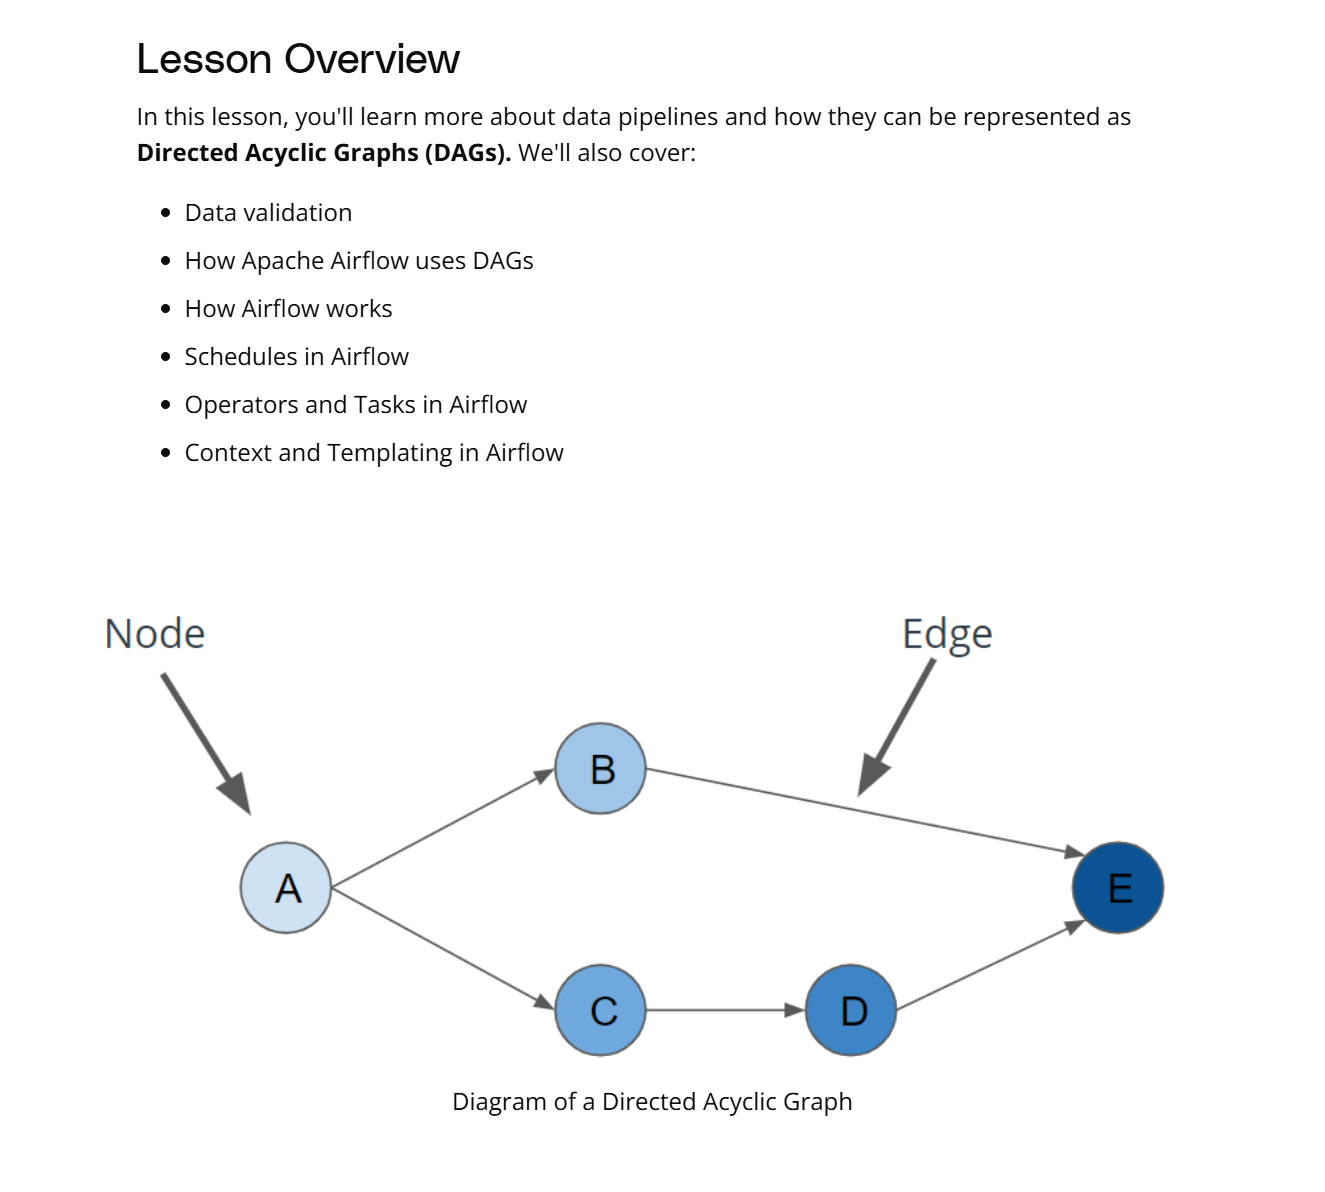

## DAGs and Data Pipelines

https://www.youtube.com/watch?v=YcahqfpcDeA

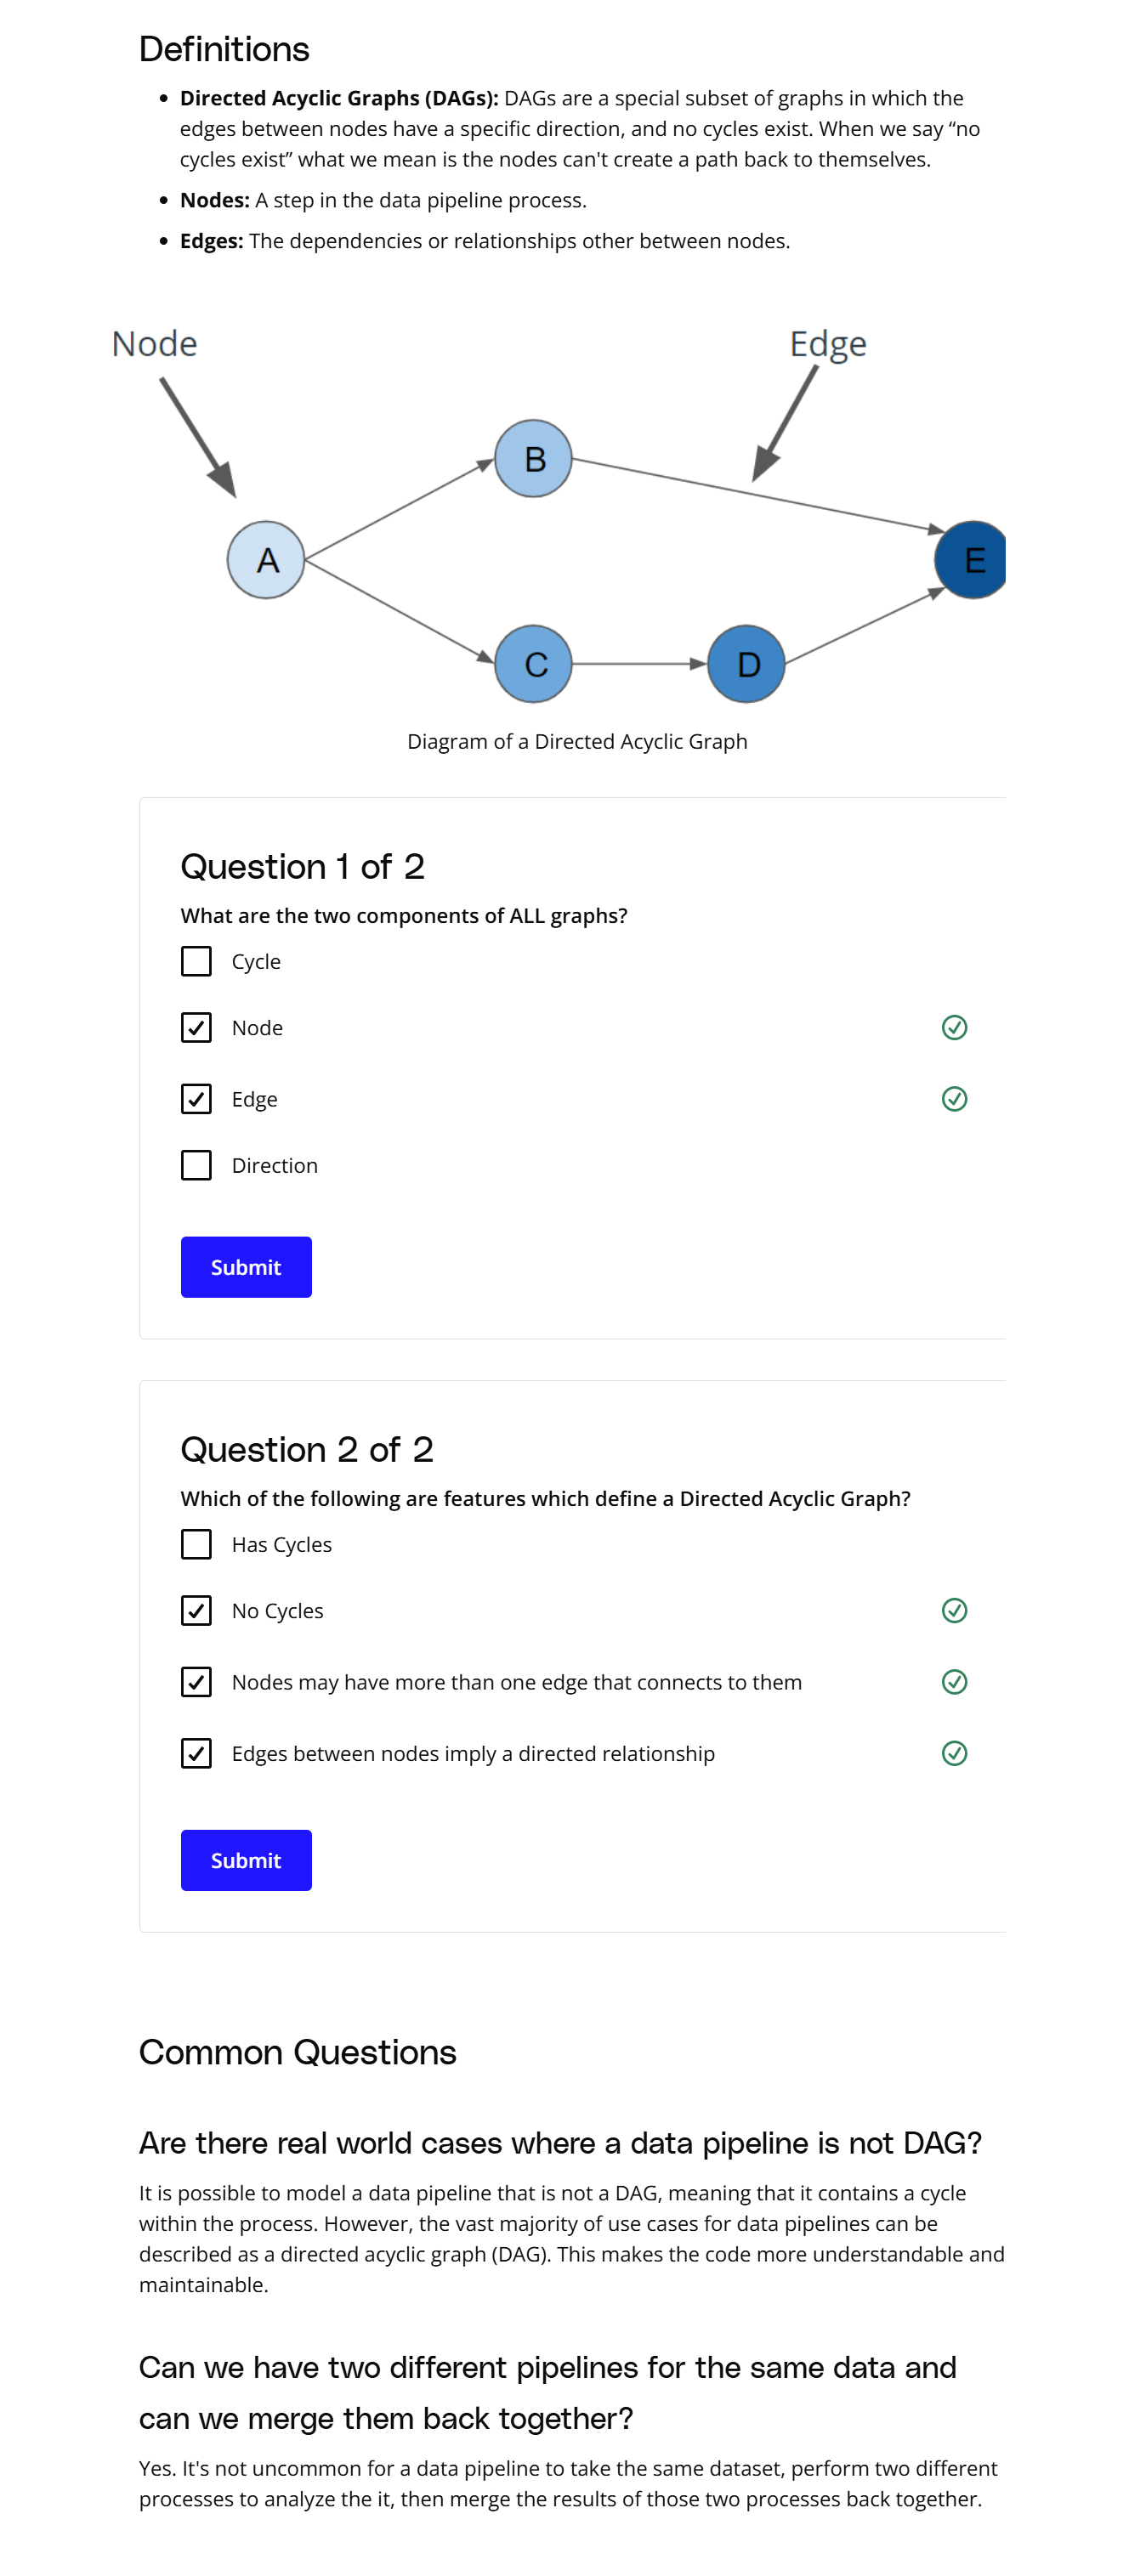

## Bikeshare DAG

https://www.youtube.com/watch?v=-Z2I5i4bGS8

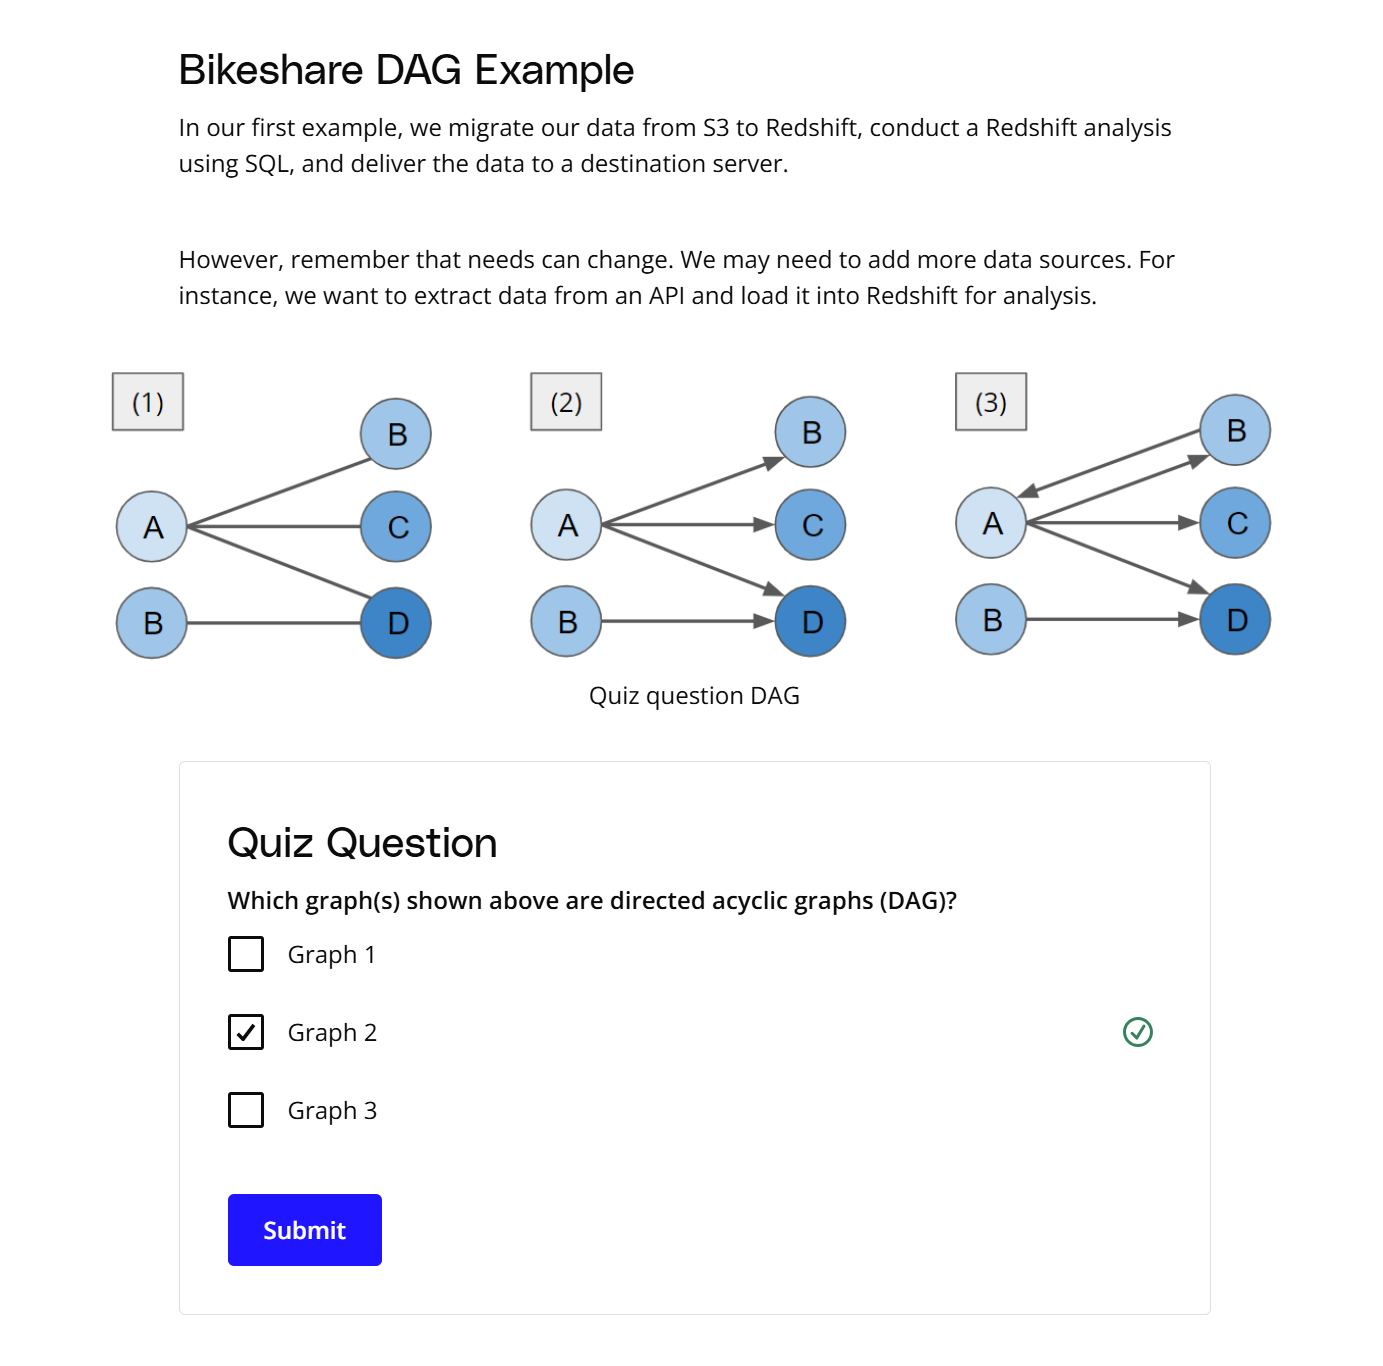

## Data Validation

https://www.youtube.com/watch?v=Y4N8CQbfExM

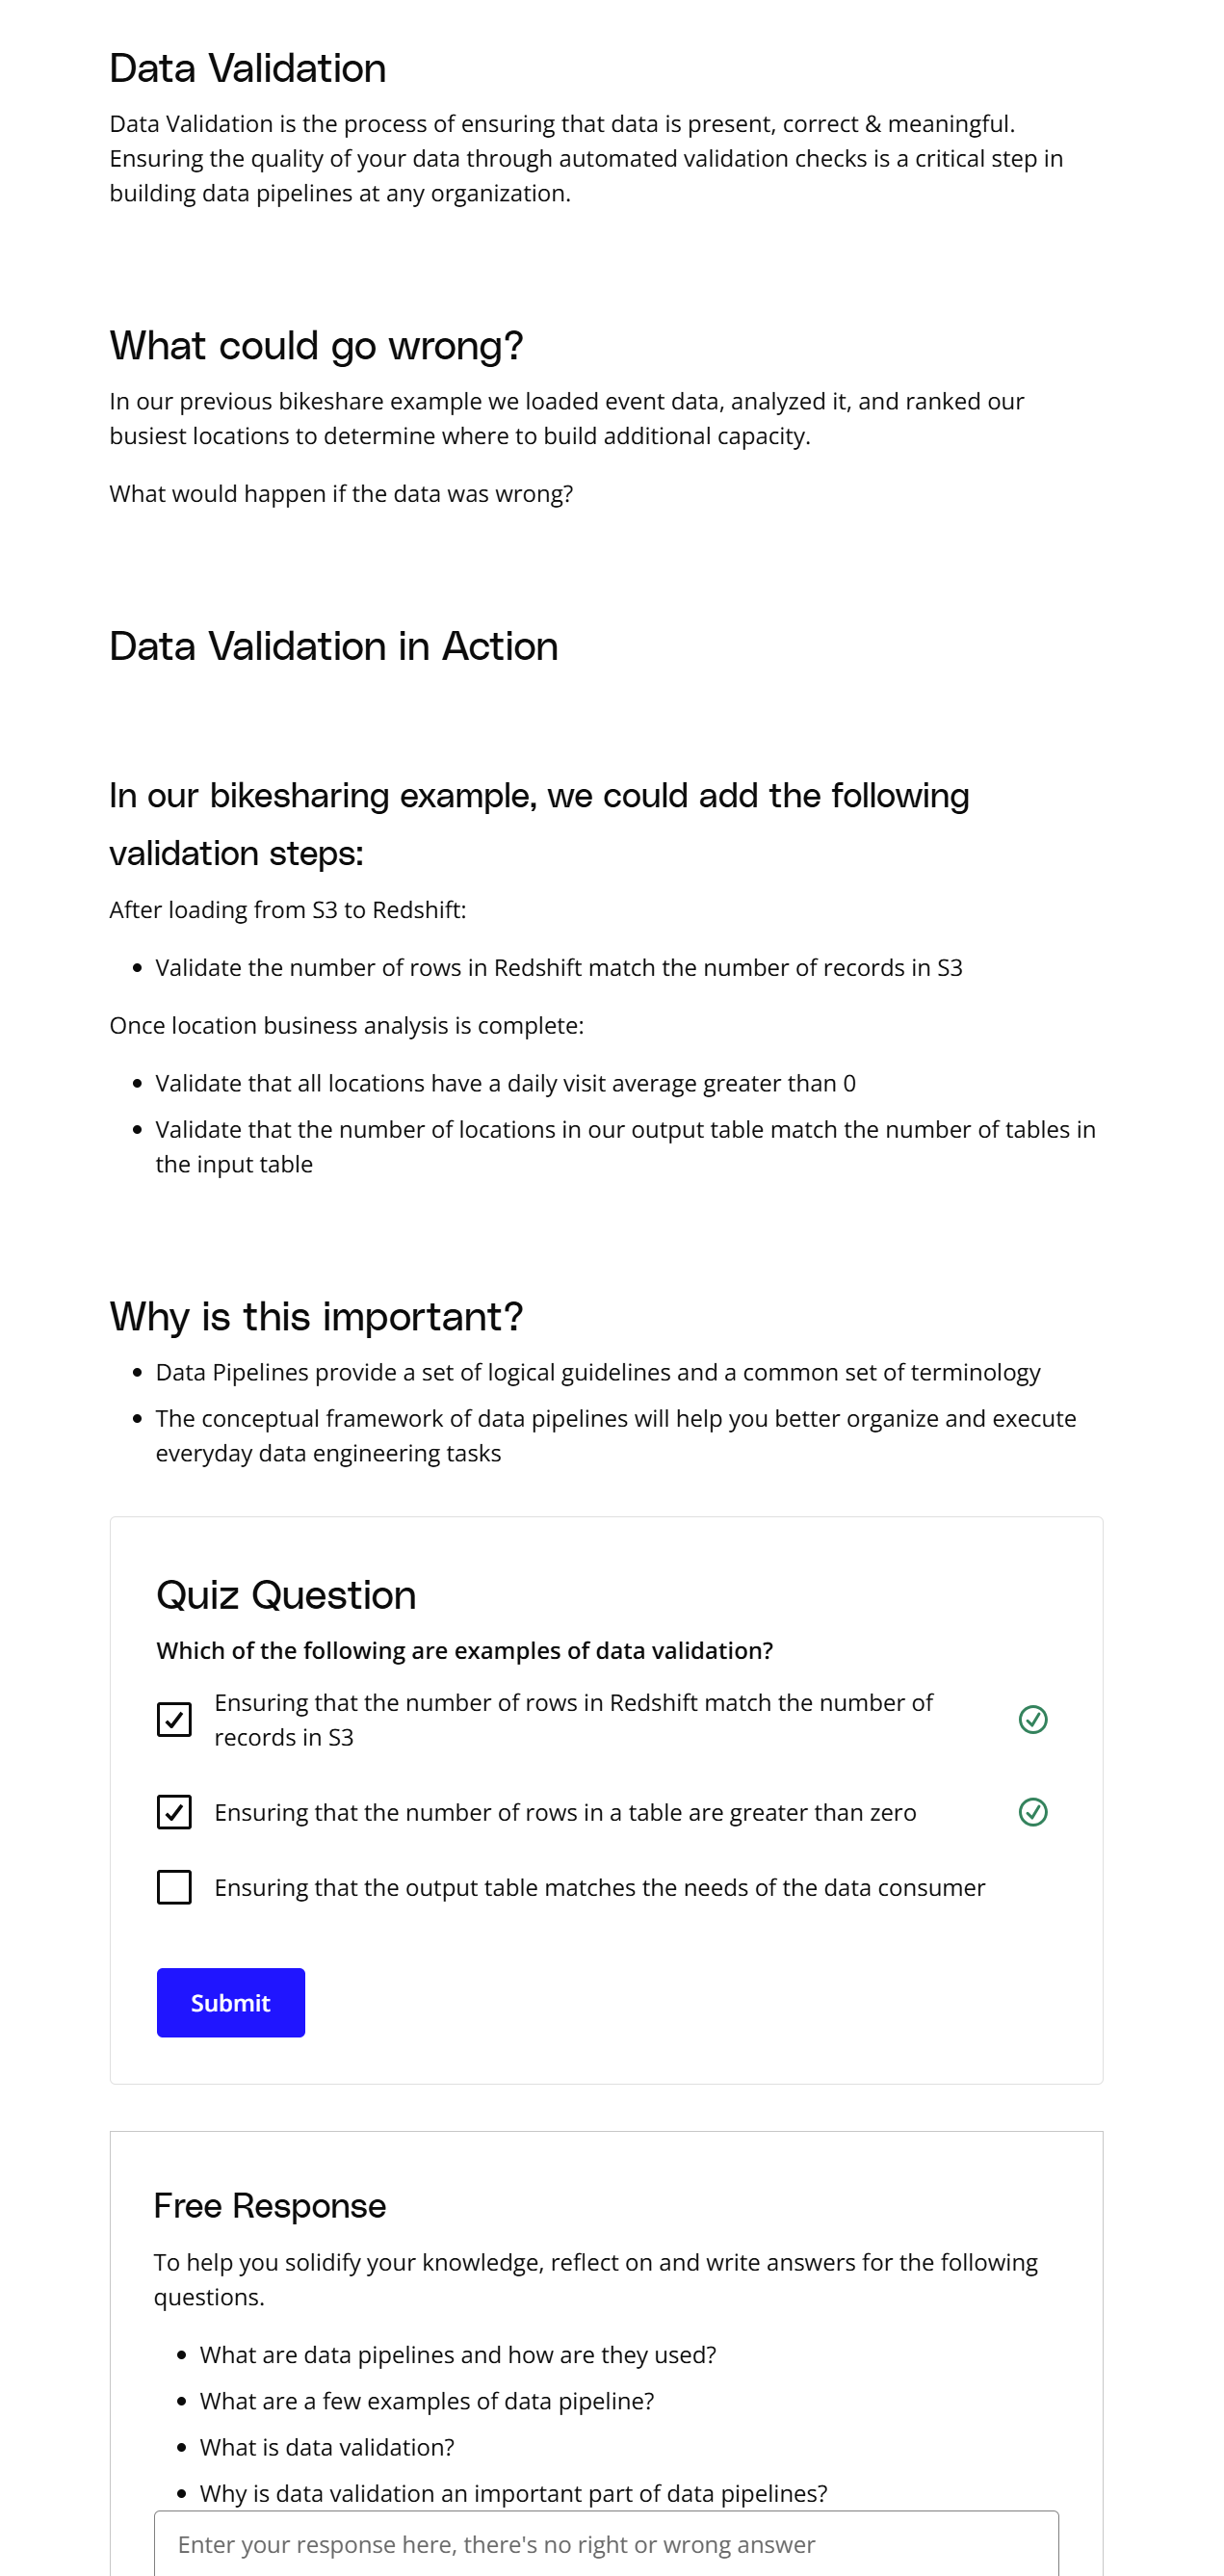

## Introduction to Apache Airflow

https://www.youtube.com/watch?v=GTW70gTpu4U

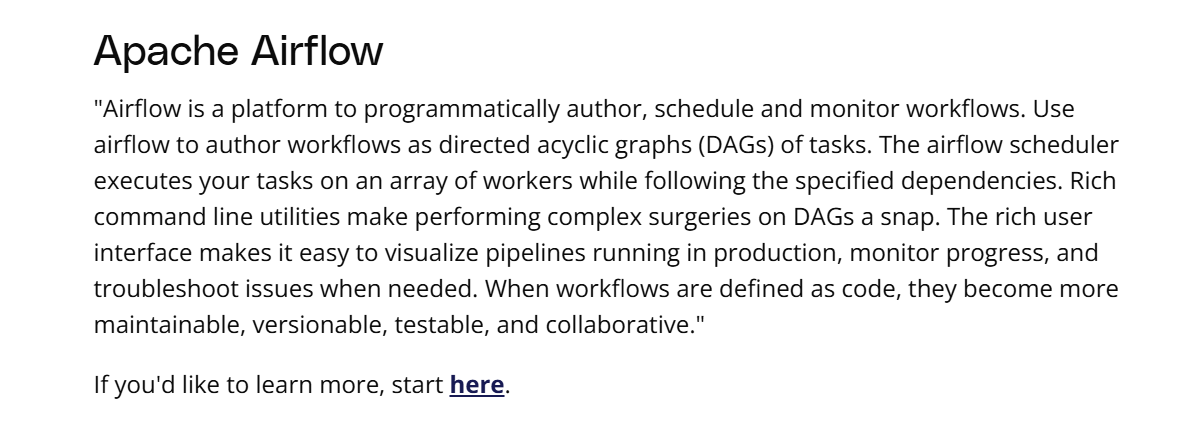

https://airflow.apache.org/

## Workspace Instructions

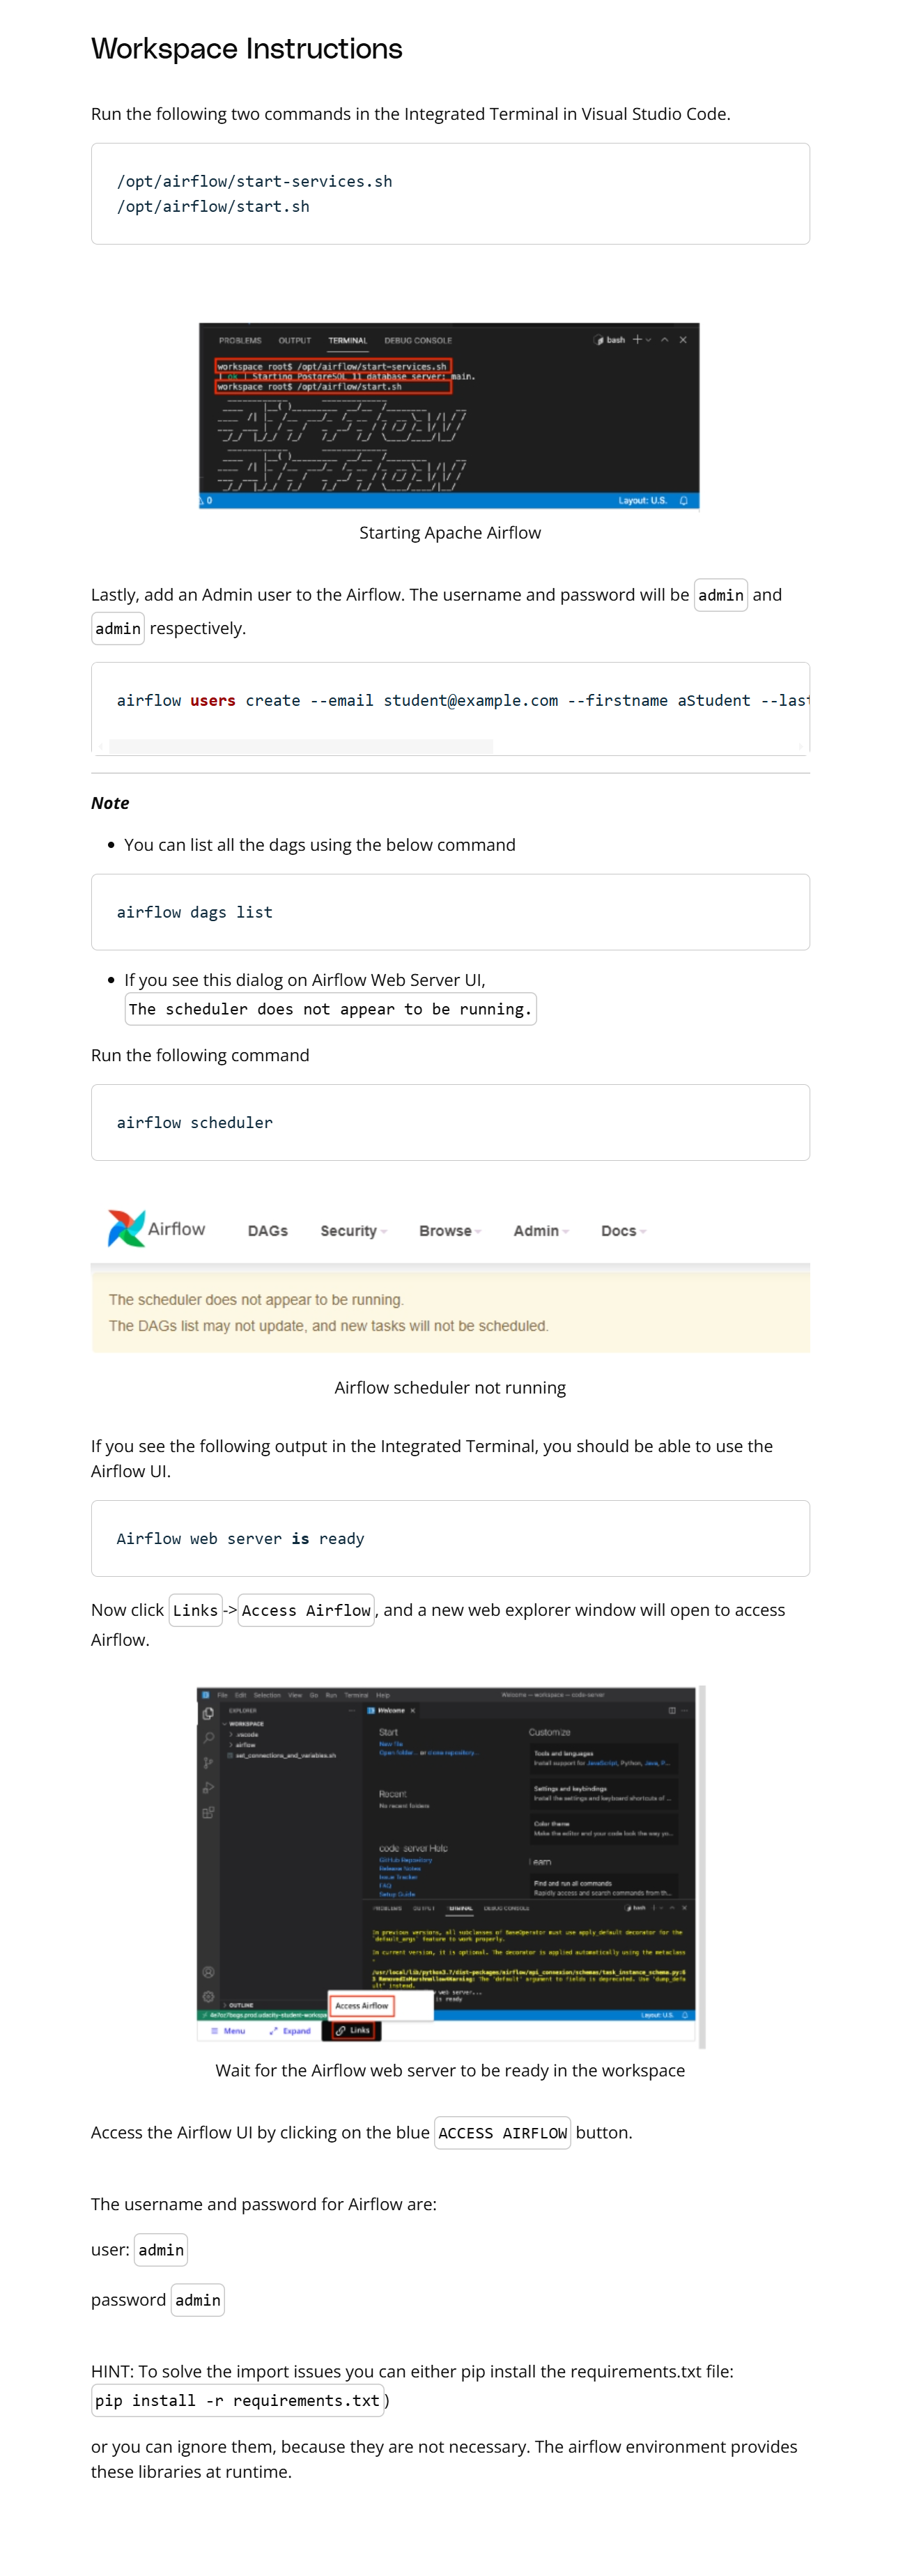

## Solution 1: Airflow DAGs

https://www.youtube.com/watch?v=kwsAetsWijk

In [20]:
def multiply_by_10_decorator(decorated_function):
    def wrapper(num1, num2):
        result = decorated_function(num1, num2) * 10
        return result
    return wrapper
    

In [21]:
@multiply_by_10_decorator
def add(n1, n2):
    return n1 + n2

In [22]:
add(2, 3)

50

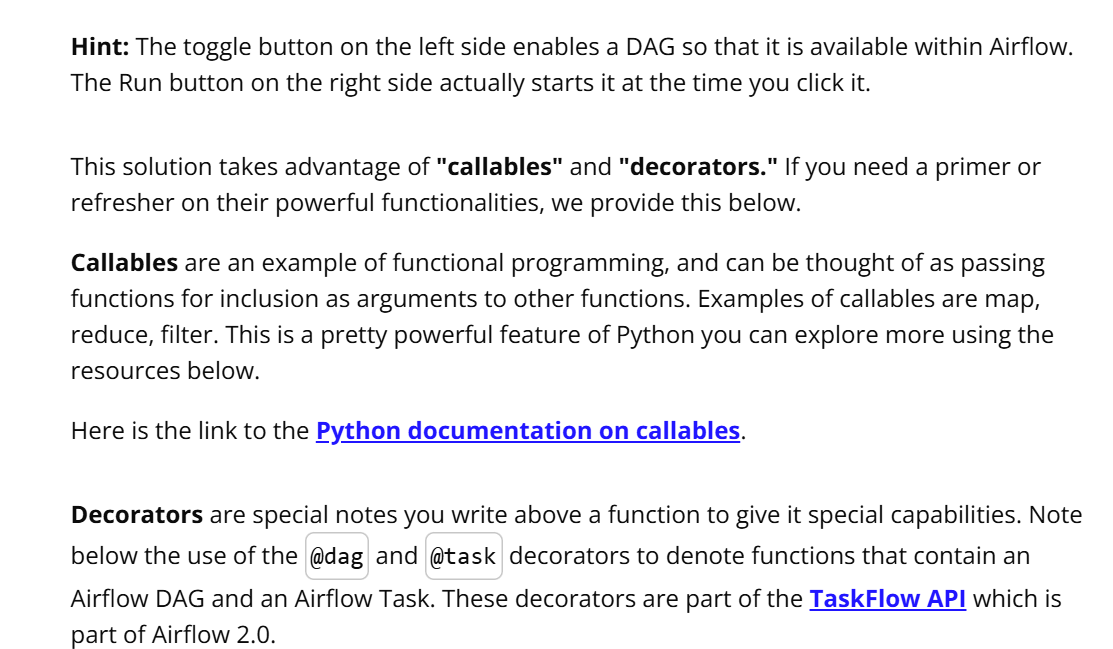

In [1]:
# definition of the decorator function
def multiply_by_100_decorator(decorated_function):
    def wrapper(num1, num2):
        result = decorated_function(num1, num2) * 100
        return result

    return wrapper


# definition of the `add` function decorated with the `multiply_by_100_decorator`
@multiply_by_100_decorator
def add(num1, num2):
    return num1 + num2

In [2]:
add(7, 4)

1100

https://docs.python.org/3.4/library/functools.html

https://airflow.apache.org/docs/apache-airflow/stable/tutorial/taskflow.html

In [ ]:
import logging
import pendulum

from airflow.decorators import dag, task

# @dag decorates the greet_task to denote it's the main function
@dag(
    start_date=pendulum.now()
)
def greet_flow_dag():
    
    # @task decorates the re-usable hello_world_task - it can be called as often as needed in the DAG
    @task
    def hello_world_task():
        logging.info("Hello World!")

    # hello_world represents a discrete invocation of the hello_world_task
    hello_world=hello_world_task()

# greet_dag represents the invocation of the greet_flow_dag
greet_dag=greet_flow_dag()

Here is good documentation on the Airflow side for an introduction to Airflow decorators.

https://www.astronomer.io/guides/airflow-decorators/

## How Airflow Works

https://www.youtube.com/watch?v=0vfq6txZJ_o

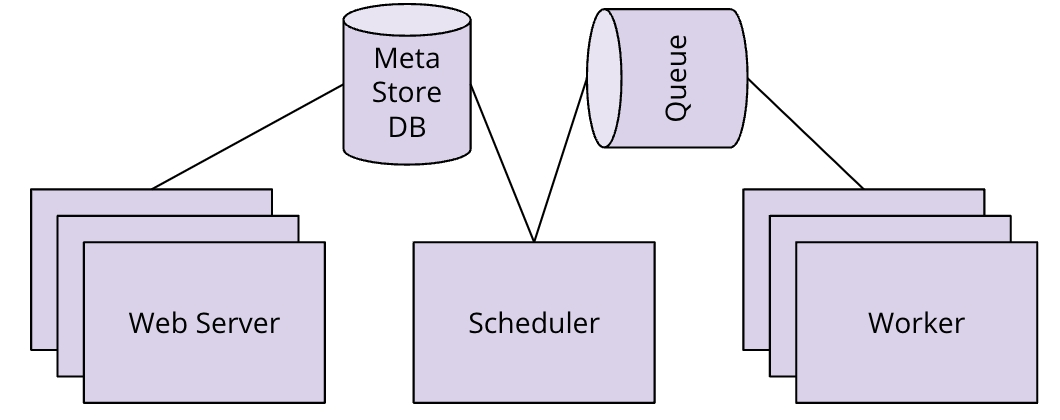

Airflow component diagram

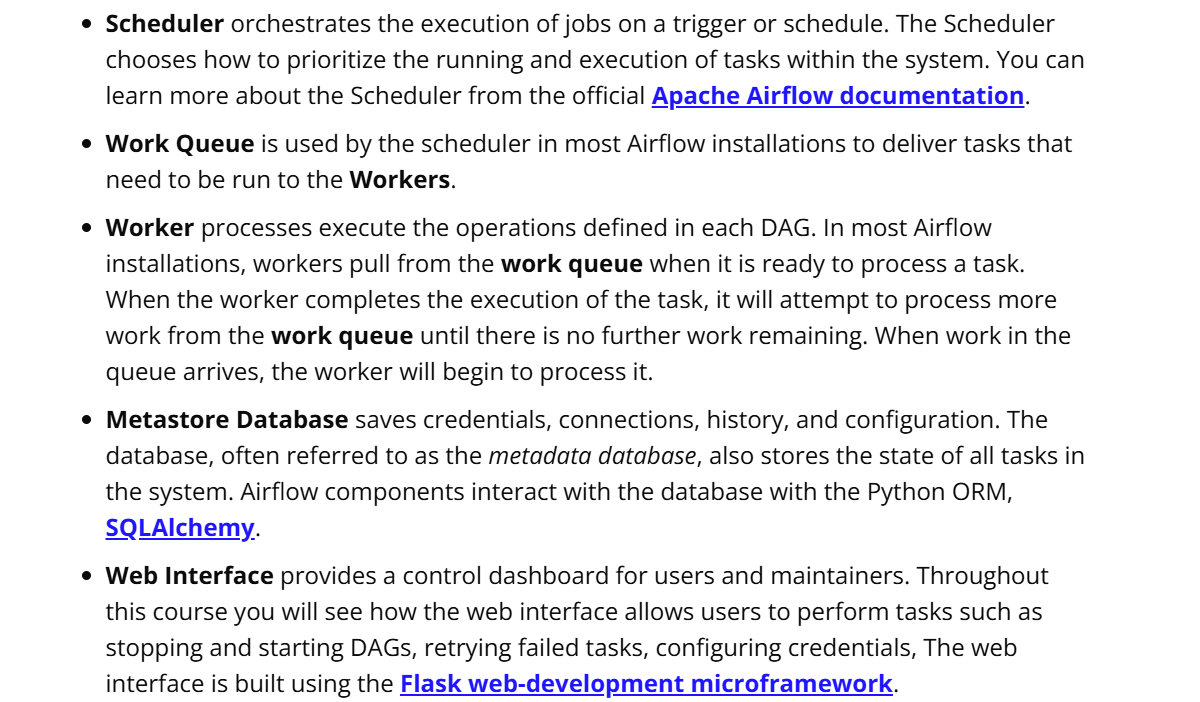

https://airflow.apache.org/scheduler.html

https://www.sqlalchemy.org/

http://flask.pocoo.org/

## How Airflow Works

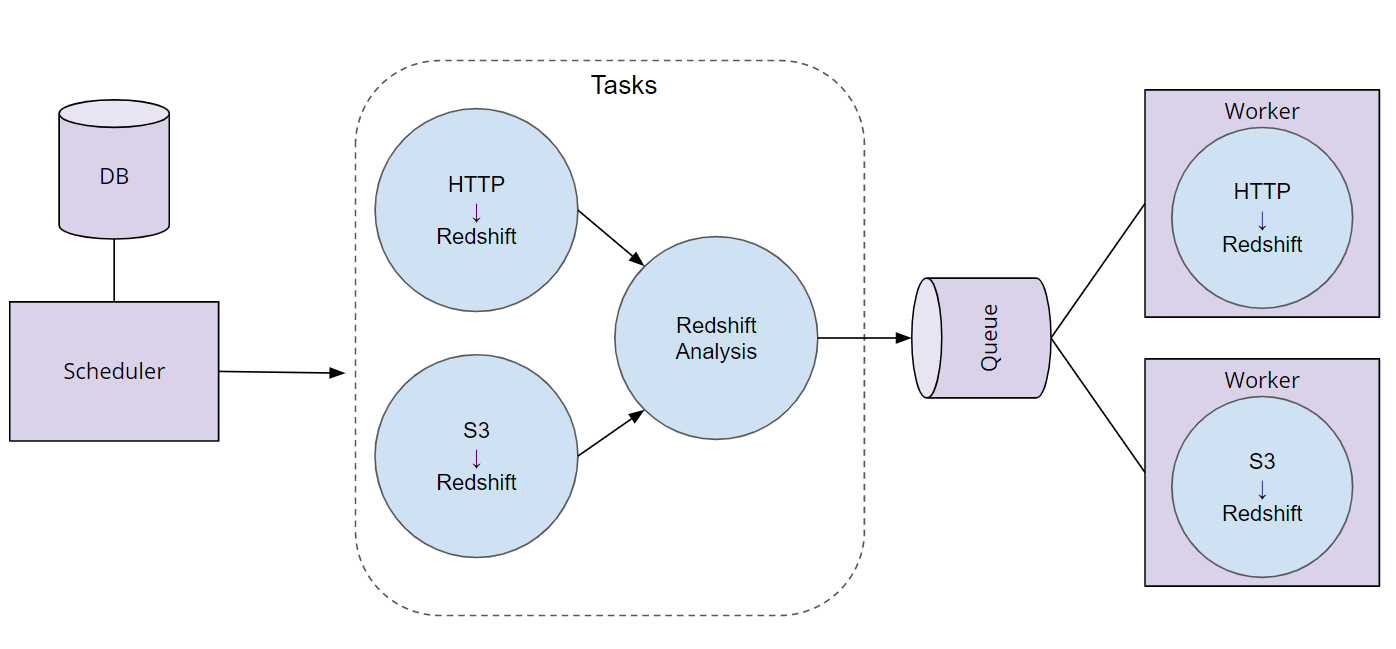

Diagram of how Airflow works

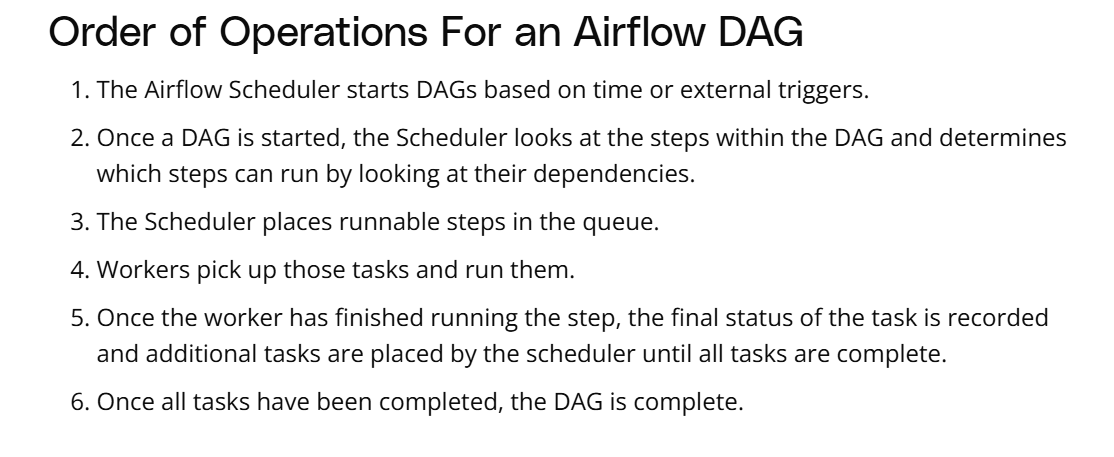

## Airflow Runtime Architecture Quiz

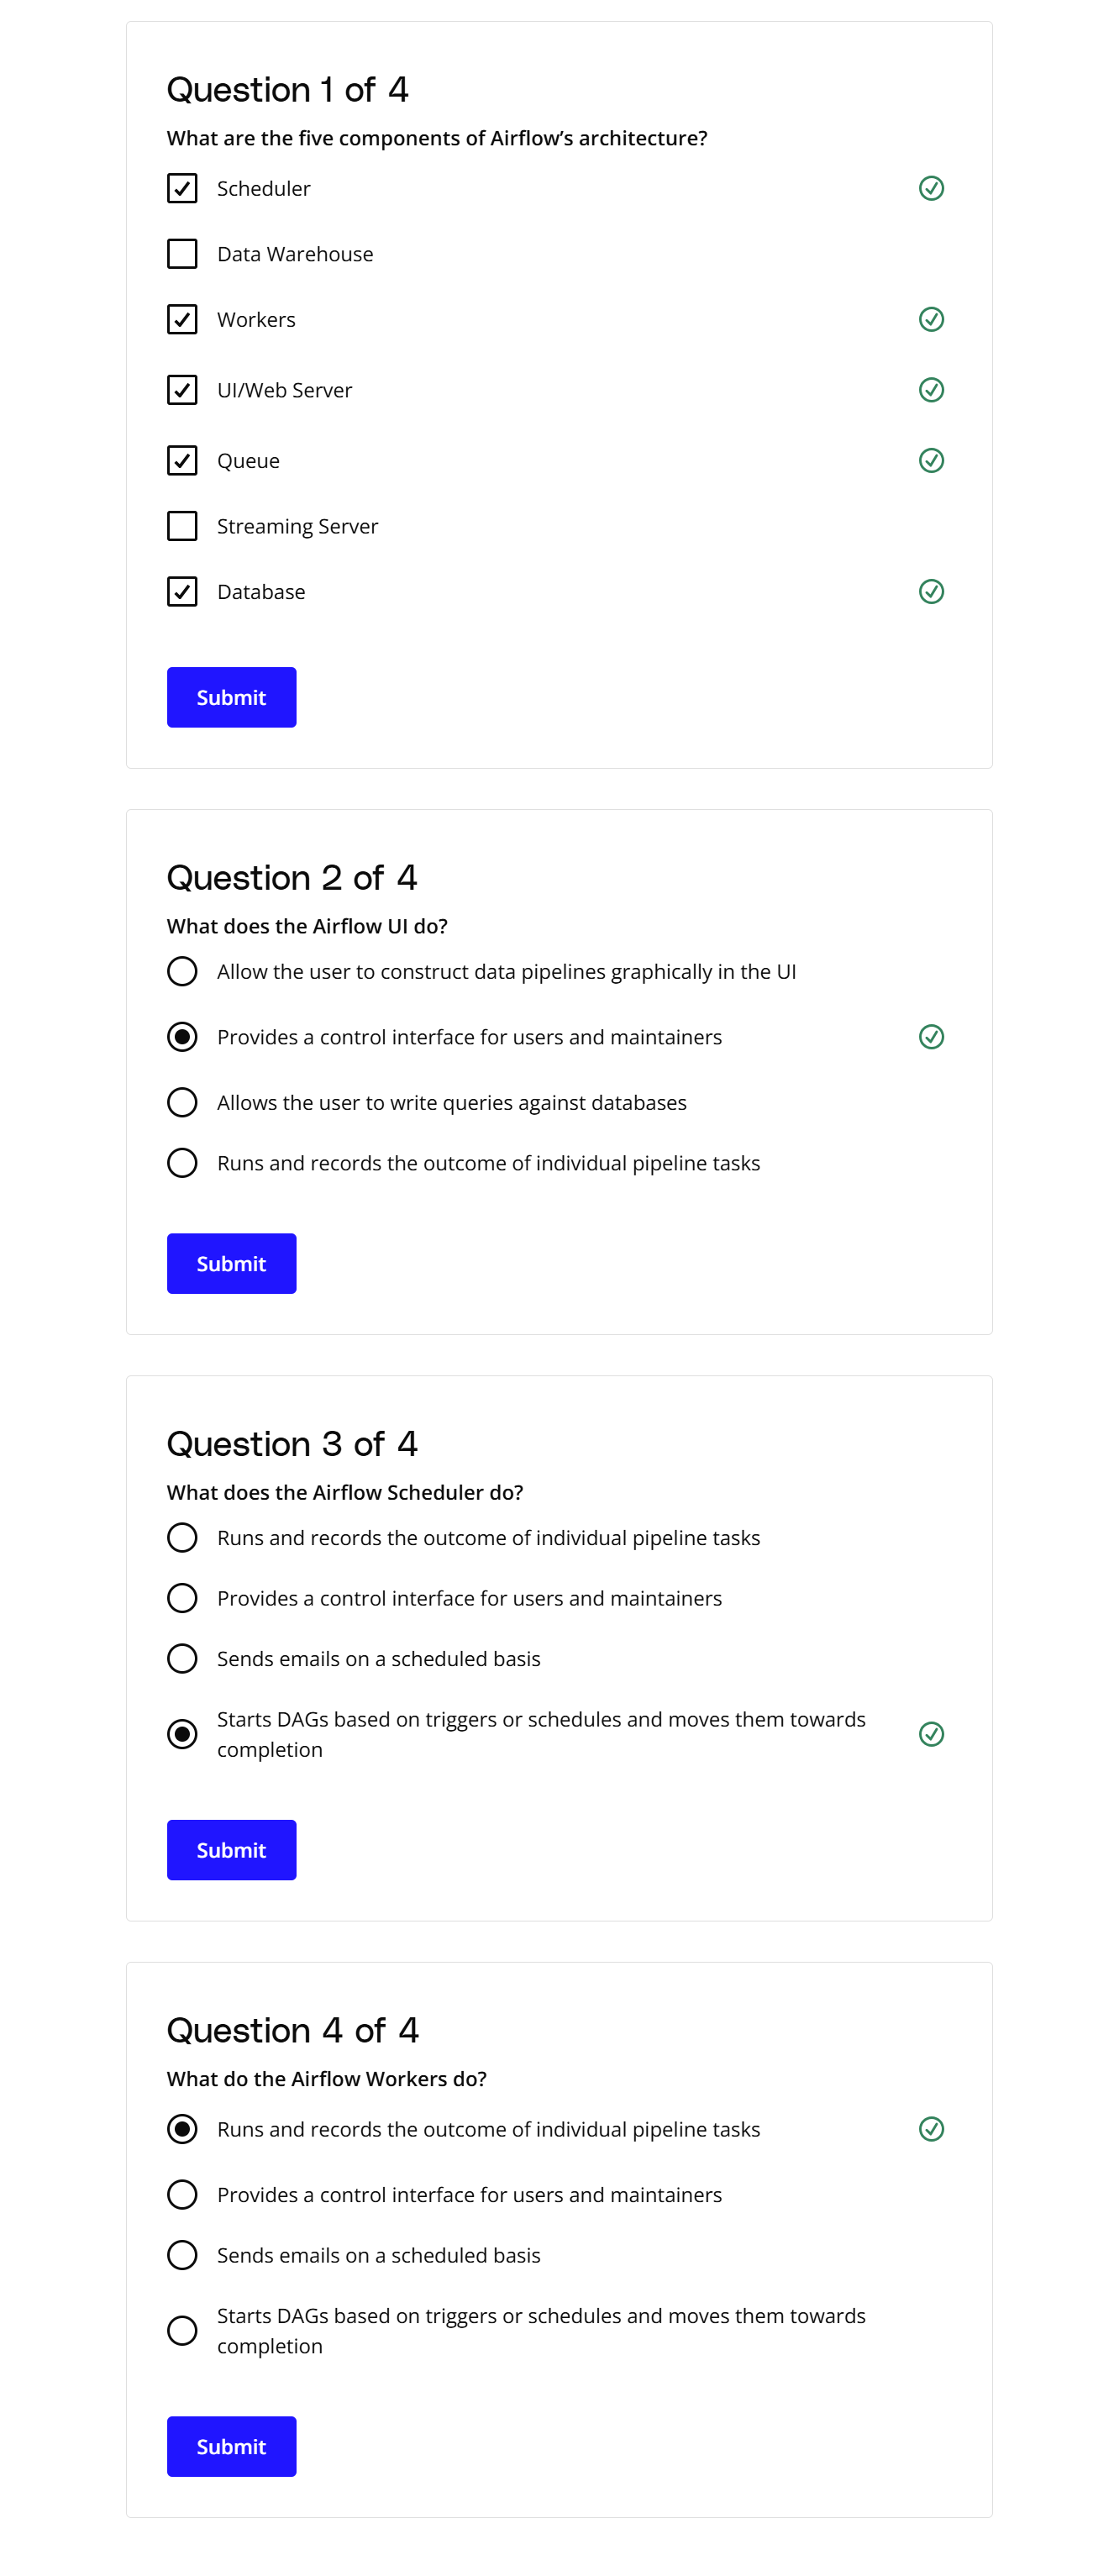

## DAGs, Operators and Tasks

https://www.youtube.com/watch?v=vW1A4cTjdks

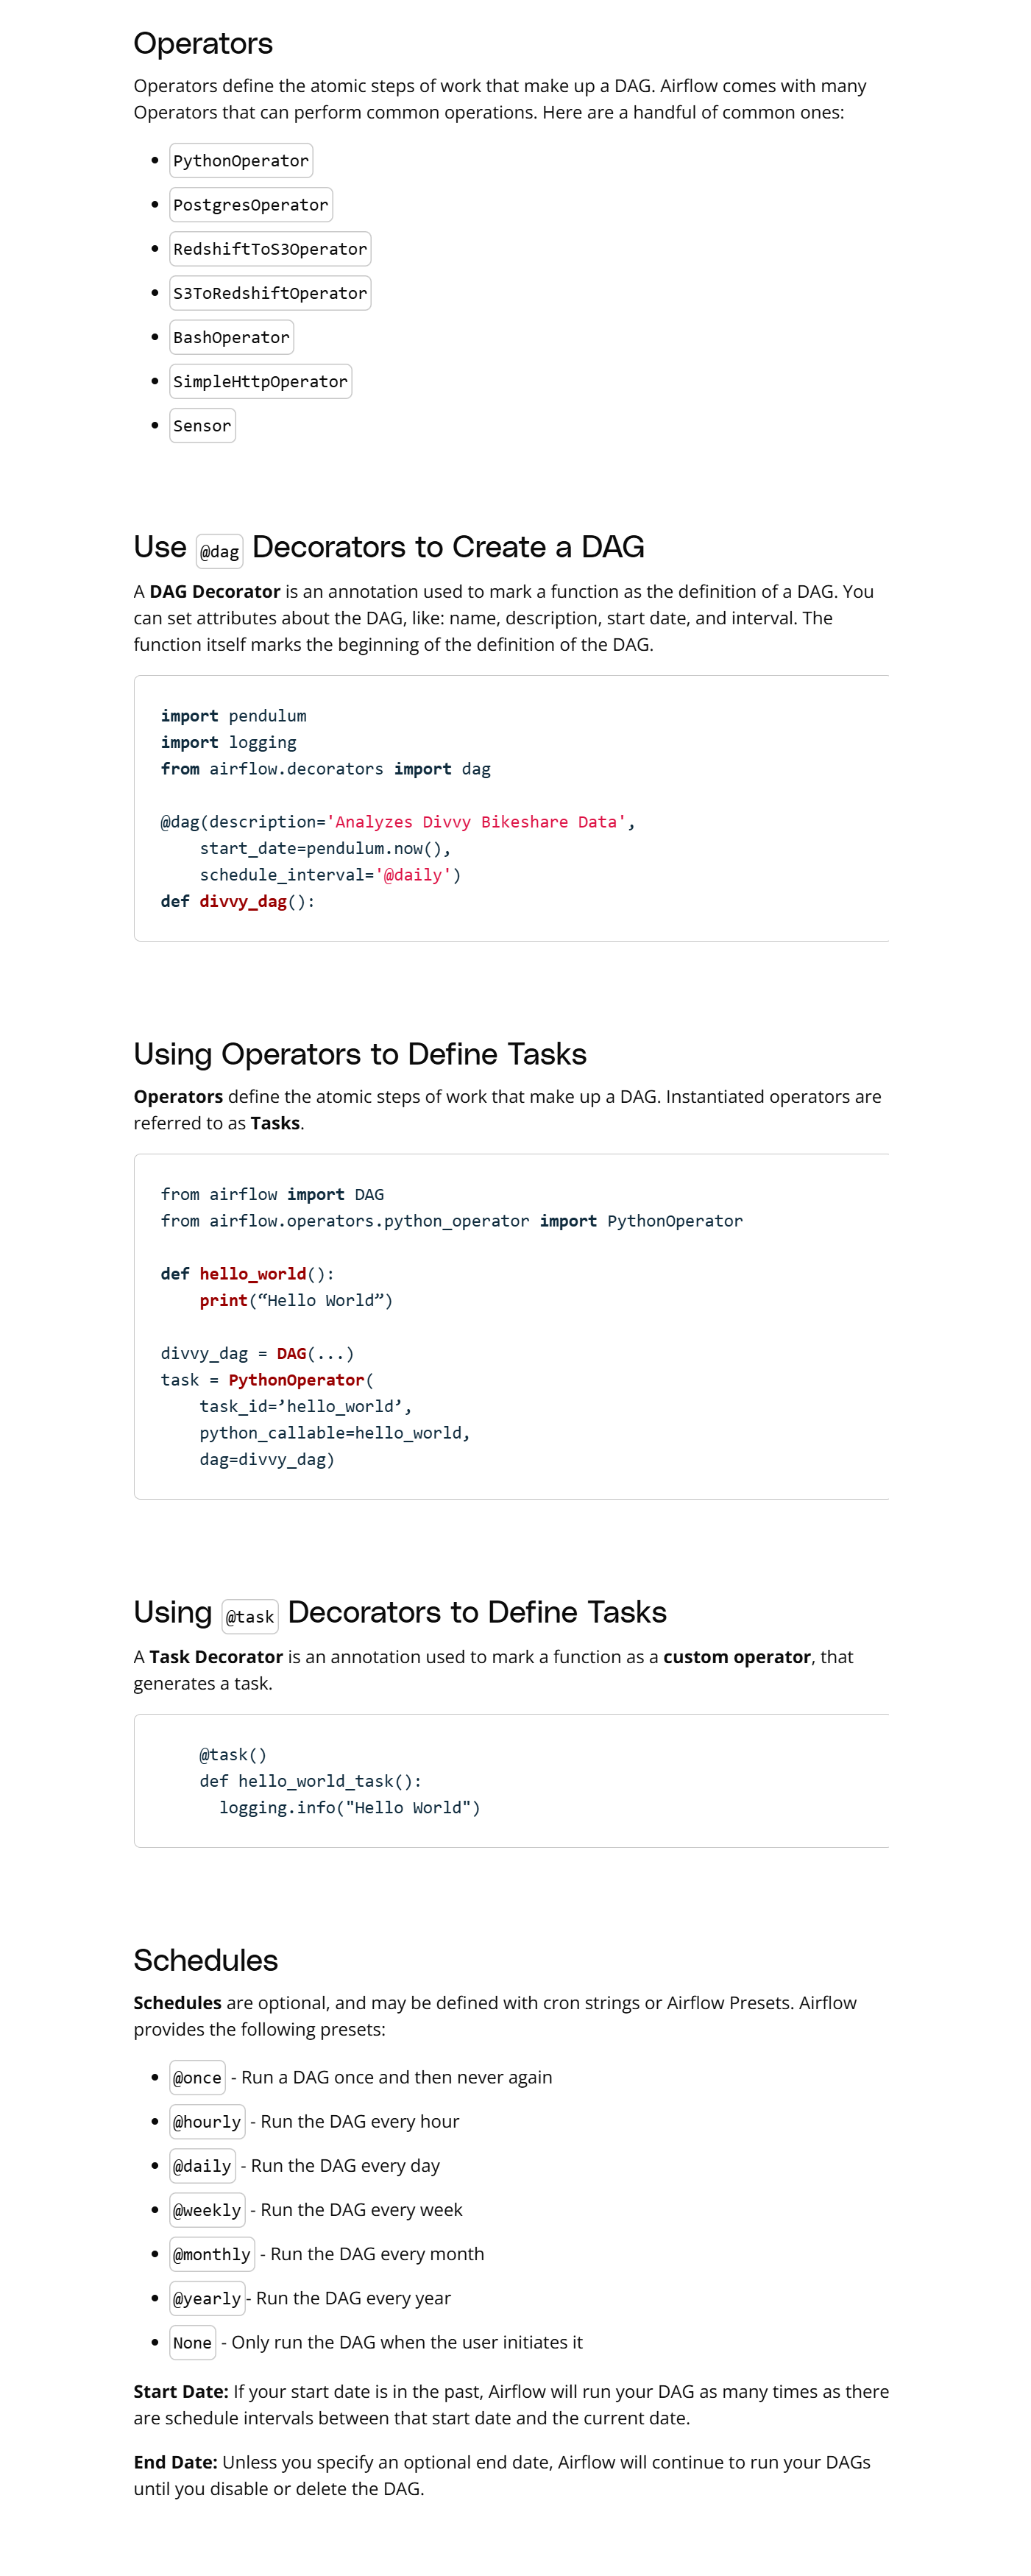

## Exercise 2: Run the Schedules

## Solution 2: Run the Schedules

https://www.youtube.com/watch?v=z-5xJIkFfmM

## Run the Schedules
Instead of using a chron job, you can set the schedule by using a DAG decorator set to an interval.

In [ ]:
import pendulum
import logging

from airflow.decorators import dag, task

@dag(
    # schedule to run daily
    # once it is enabled in Airflow
    schedule_interval='@daily',
    start_date=pendulum.now()
)
def greet_flow():

    @task
    def hello_world():
        logging.info("Hello World!")

    # hello_world represents the invocation of the only task in this DAG
    # it will run by itself, without any sequence before or after another task
    hello_world_task=hello_world()

greet_flow_dag=greet_flow()

## Task Dependencies

https://www.youtube.com/watch?v=IJKsUQWz_Vo

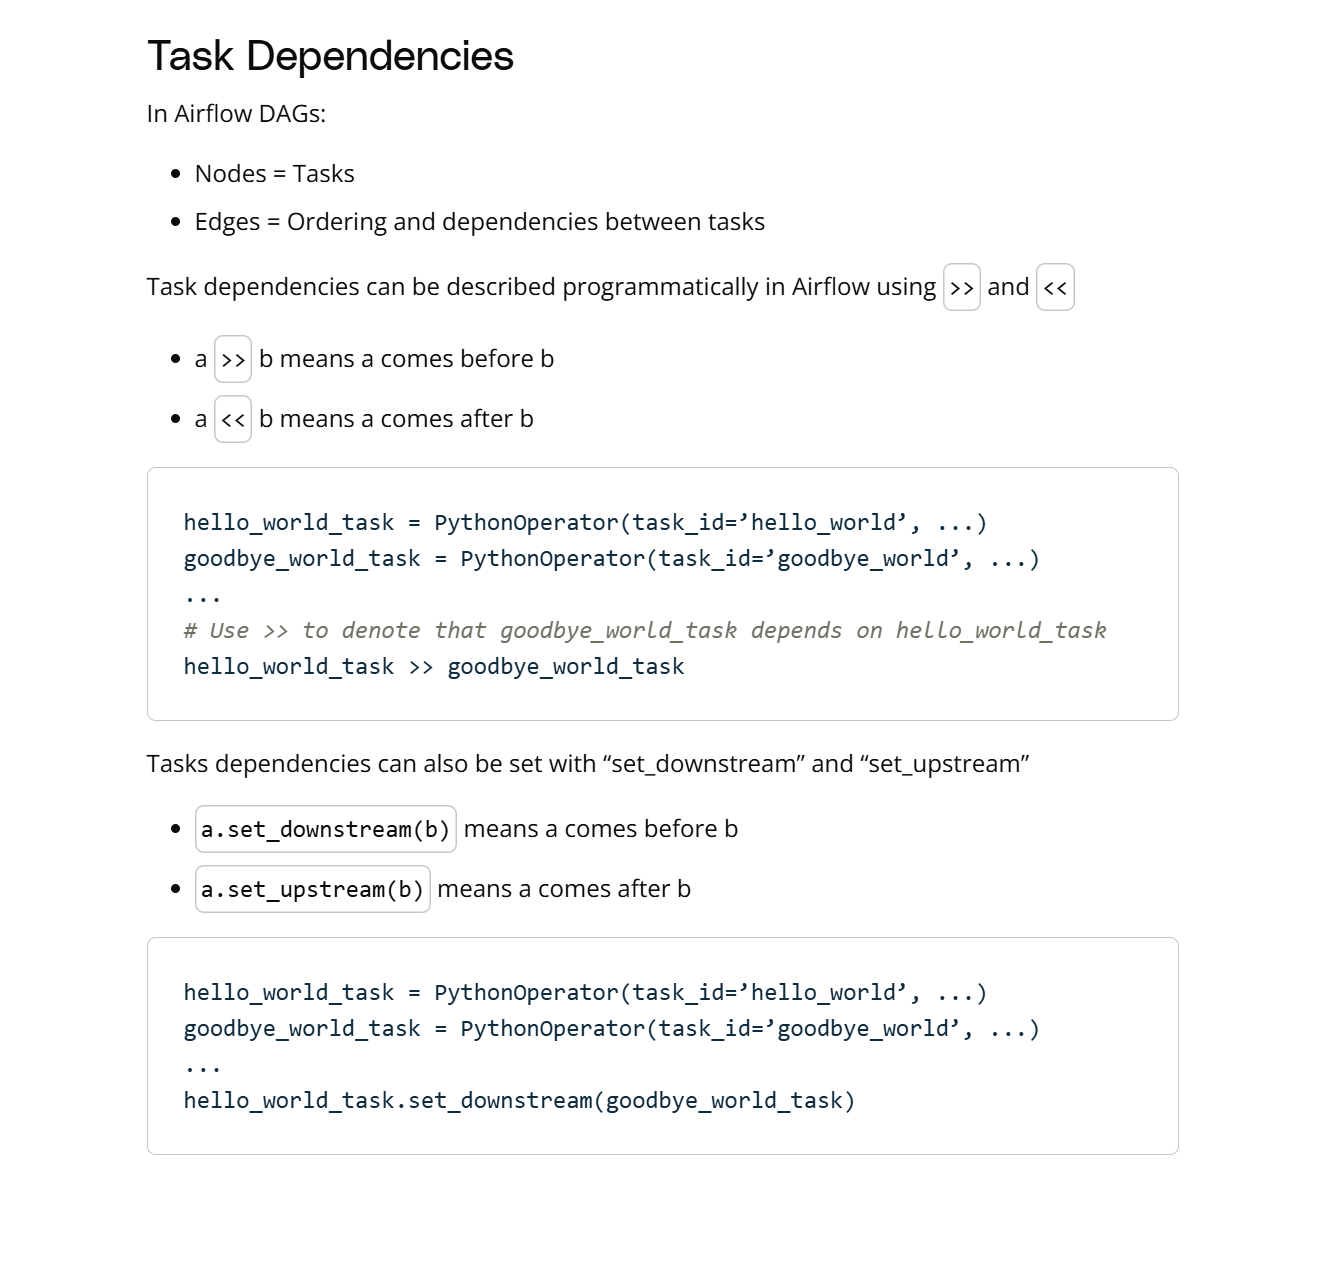

## Exercise 3: Task Dependencies

## Solution 3: Task Dependencies

https://www.youtube.com/watch?v=Tk7oq7zW8rk

## Task Dependencies Solution
The >> is used to note dependencies. When creating your logic, be sure to write comments for yourself to keep track of your order of operations. Your logic must flow correctly to execute. When writing complex task dependencies, be sure to start small. Use incremental changes in order to understand your logic flow and slowly build until you get to the end goal of a complex structure.

In [ ]:
import pendulum
import logging

from airflow.decorators import dag, task

@dag(
    schedule_interval='@hourly',
    start_date=pendulum.now()
)
def task_dependencies():

    # the hello_world task doesn't accept parameters
    @task()
    def hello_world():
        logging.info("Hello World")

    # the addition task accepts two parameters and adds them together
    # logs the result, and returns it
    @task()
    def addition(first,second):
        logging.info(f"{first} + {second} = {first+second}")
        return first+second

    # the subtraction task accepts two parameters, and subracts the 
    # second from the first, then logs and returns the result
    @task()
    def subtraction(first,second):
        logging.info(f"{first} - {second} = {first-second}")
        return first-second

    # the division task accepts two parameters, and divides the first
    # by the second, logs and returns the result
    @task()
    def division(first,second):
        logging.info(f"{first} / {second} = {int(first/second)}")   
        return int(first/second)     

    # hello represents a discrete invocation of hello world
    hello=hello_world()

    # two_plus_two represents the invocation of addition with 2 and 2
    two_plus_two=addition(2,2)

    # two_from_six represents the invocation of subtraction with 6 and 2
    two_from_six=subtraction(6,2)

    # eight_divided_by_two represents the invocation of division with 8 and 2
    eight_divided_by_two = division(8,2)

    # sum represents the invocation of addition with 5 and 5
    sum= addition(5,5)

    # difference represents the invocation of subtraction with 6 and 4
    difference = subtraction(6,4)

    # sum_divided_by_difference represents the invocation of division with the sum and the difference
    sum_divided_by_difference = division(sum,difference)

    # hello to run before two_plus_two and two_from_six
    hello >> two_plus_two 
    hello >> two_from_six

    # Notice, addition and subtraction can run at the same time

    # two_plus_two to run before eight_divided_by_two
    two_plus_two >> eight_divided_by_two

    # two_from_six to run before eight_divided_by_two
    two_from_six >> eight_divided_by_two


    # Notice division waits for subtraction and addition to run

    # sum to run before sum_divided_by_difference
    sum >> sum_divided_by_difference

    # difference to run before sum_divided_by_difference
    difference >> sum_divided_by_difference

task_dependencies_dag=task_dependencies()


## Airflow Hooks

https://www.youtube.com/watch?v=2Vkh9rfh6vE

## Connection via Airflow Hooks
Connections can be accessed in code via hooks. Hooks provide a reusable interface to external systems and databases. With hooks, you don’t have to worry about how and where to store these connection strings and secrets in your code.

In [ ]:
from airflow import DAG
from airflow.hooks.postgres_hook import PostgresHook
from airflow.operators.python_operator import PythonOperator

def load():
# Create a PostgresHook option using the `demo` connection
    db_hook = PostgresHook(‘demo’)
    df = db_hook.get_pandas_df('SELECT * FROM rides')
    print(f'Successfully used PostgresHook to return {len(df)} records')

load_task = PythonOperator(task_id=’load’, python_callable=hello_world, ...)

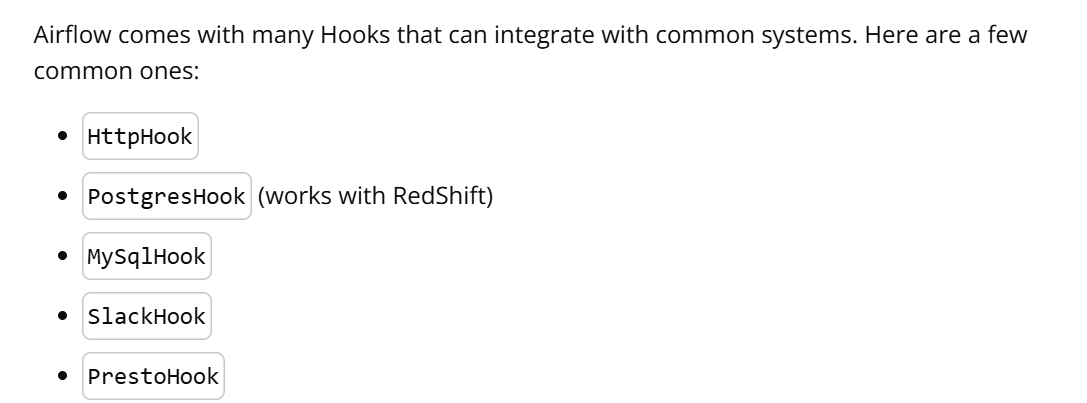

## Quiz: Review of Pipeline Components

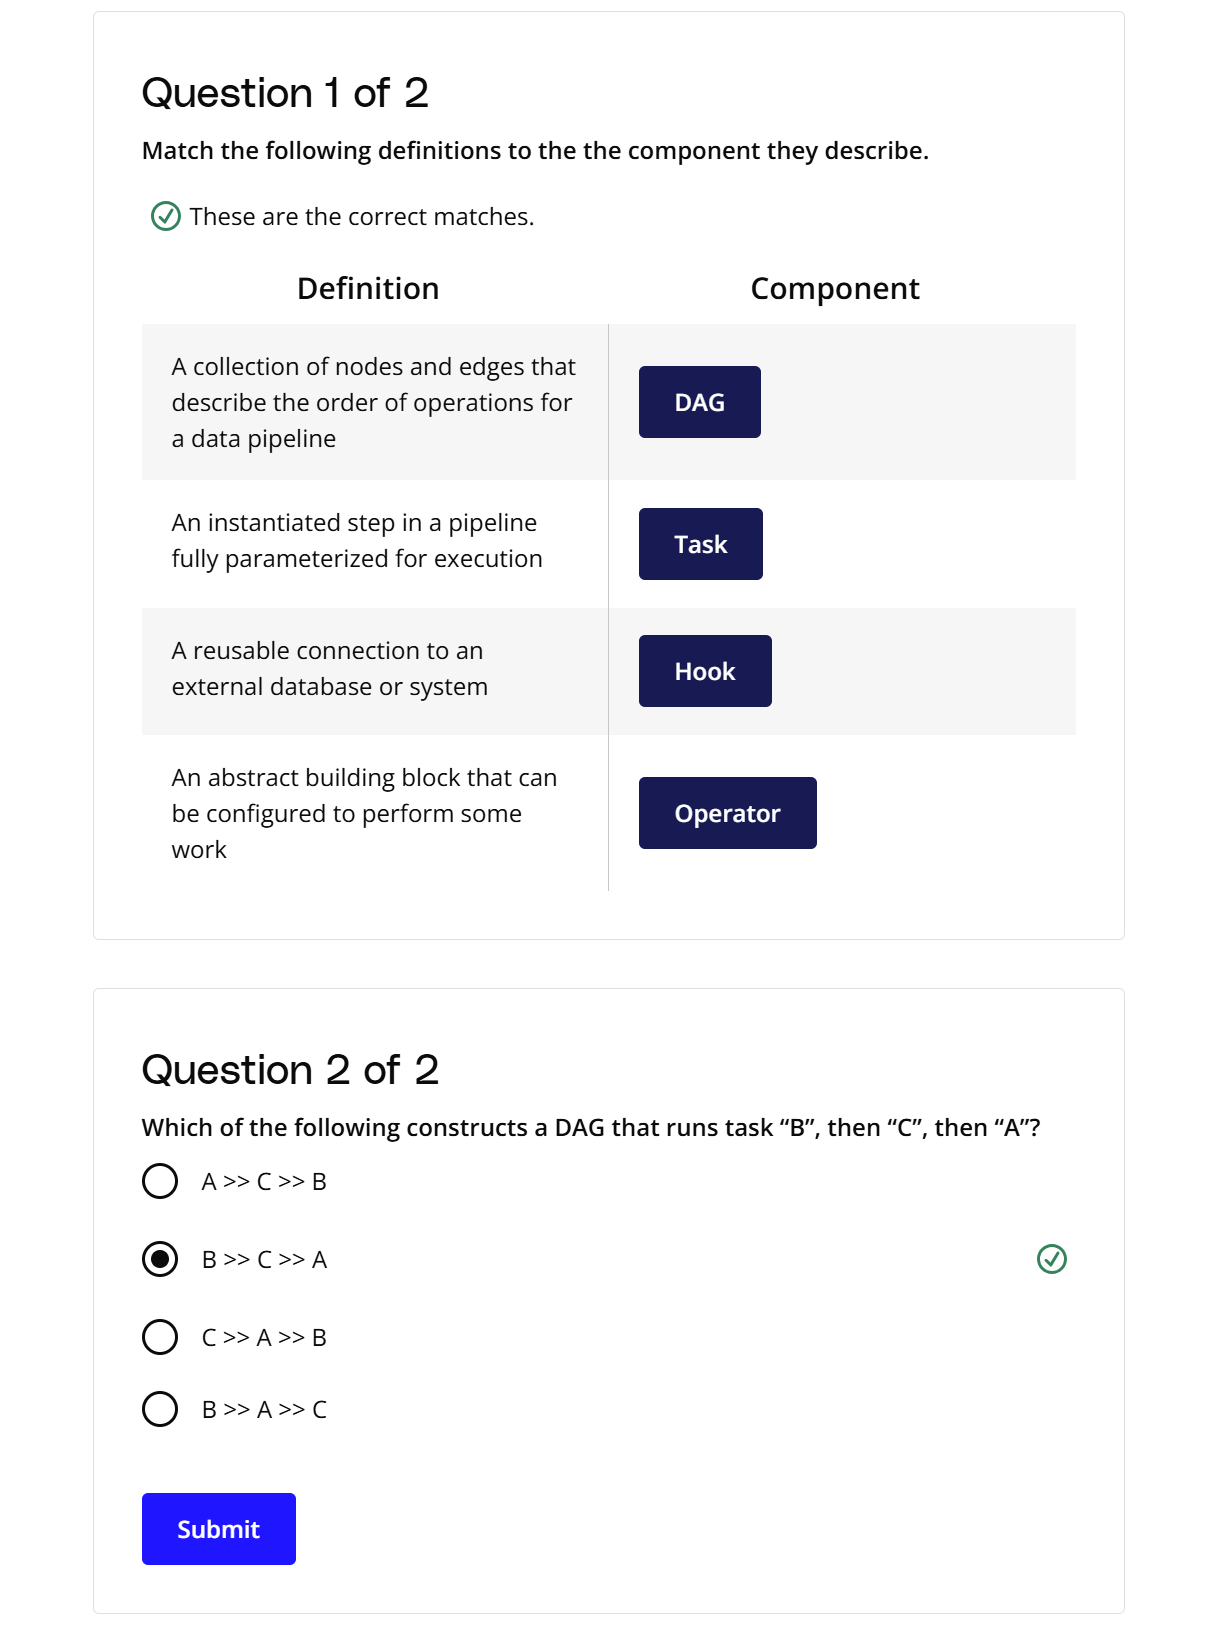

## Context and Templating

## Context Variables
Airflow leverages templating to allow users to “fill in the blank” with important runtime variables for tasks. We use the **kwargs parameter to accept the runtime variables in our task.

In [ ]:
from airflow.decorators import dag, task

@dag(
  schedule_interval="@daily";
)
def template_dag(**kwargs):

  @task
  def hello_date():
    print(f“Hello {kwargs['ds']}}”)

Here(opens in a new tab) is the Apache Airflow Templates reference

https://airflow.apache.org/docs/apache-airflow/stable/templates-ref.html

## Exercise 4: Context and Templating

## Solution 4: Context and Templating

https://www.youtube.com/watch?v=T9Axx2R4ft8

In [ ]:
import logging
import pendulum

from airflow.decorators import dag, task
from airflow.models import Variable

@dag(
    start_date=pendulum.now(),
    schedule_interval="@daily"
)
def log_details():

    @task
    def log_execution_date(**kwargs):
        logging.info(f"Execution date is {kwargs['ds']}")

    @task
    def log_run_id(**kwargs):
        logging.info(f"My run id is {kwargs['run_id']}")
    
    @task
    def log_previous_run(**kwargs):
        logging.info(f"My previous run was on {kwargs['prev_start_date_success']}")
    
    @task
    def log_next_run(**kwargs):
        logging.info(f"My next run will be {kwargs['next_execution_date']}")


    log_execution_date_task=log_execution_date()
    log_run_id_task=log_run_id()
    log_previous_run_task=log_previous_run()
    log_next_run_task=log_next_run()

log_details_dag = log_details()

https://www.youtube.com/watch?v=wIrBgpXq3rc

## Putting it All Together
Airflow allows flexibility, code-based artifacts, and decoupling from the scheduler and scheduled tasks. Use Python to create your DAG and detail task sequences and code dependencies.

## Lesson Review

https://www.youtube.com/watch?v=LIA6mm-PUGY

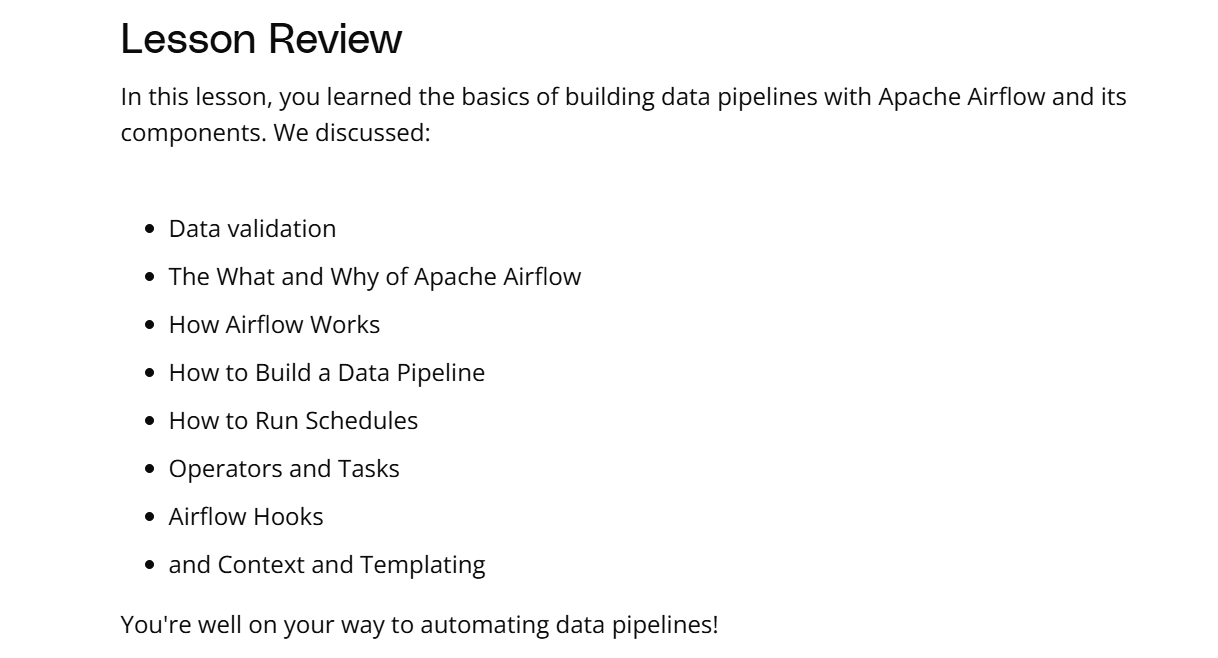

## Lesson Overview

https://www.youtube.com/watch?v=jG3coG03z3g

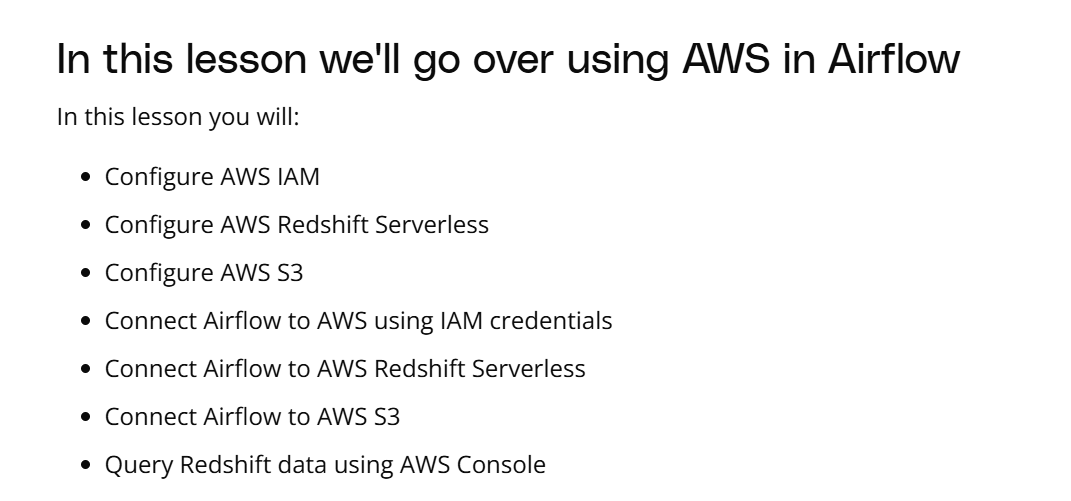